In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

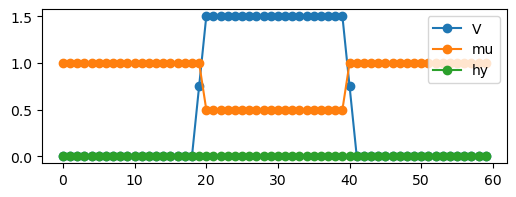

In [11]:
widthD = 20
widthN = 20
X, Y = widthN+widthD+widthN, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muD = 0.5 * t
muN = 1.0 * t
mu = np.zeros(lattice.X)
mu[:widthN] = muN
mu[widthN:widthN+widthD] = muD
mu[widthN+widthD:widthN+widthD+widthN] = muN

h0 = 0.9 * t
hy = np.zeros_like(mu)

U=None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[:widthN] = 0
V[widthN+widthD:widthN+widthD+widthN] = 0
V[widthN-1] = V0/2
V[widthN+widthD] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hy, '-o', label='hy')

plt.legend()

In [14]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1])

In [15]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-6, rtol=1e-3, maxiter=500, verbose=True, temperature=T)

F0:
Absolute error: 0.07703193000412235
Relative error: 77031930004.12234
Average old: 0j
Average: (0.005814678506131721+0j)
F_xplus:
Absolute error: 0.38912165831710305
Relative error: 74196241285.89983
Average old: (0.03728813559322034+0j)
Average: (0.07060324916661516+0j)
F_xmin:
Absolute error: 0.3907007985807392
Relative error: 76704734185.02798
Average old: (0.03728813559322034+0j)
Average: (0.07232561155113329+0j)
F_yplus:
Absolute error: 0.3919977026054842
Relative error: 103198527976.92046
Average old: (-0.03666666666666667+0j)
Average: (-0.07366151163125087-1.5850953633956574e-18j)
F_ymin:
Absolute error: 0.3919977026054842
Relative error: 103198527976.92046
Average old: (-0.03666666666666667+0j)
Average: (-0.07366151163125087+1.5850953633956574e-18j)
Fuu_xplus:
Absolute error: 2.5782133862982595e-17
Relative error: 2.5782133862982593e-05
Average old: 0j
Average: (3.985785229980847e-20+0j)
Fuu_xmin:
Absolute error: 2.3478376583317985e-17
Relative error: 2.3478376583317984e-05

In [16]:
F, Fuu, Fdd = H.get_correlations()

T/t=0.001, hy/t=0.9


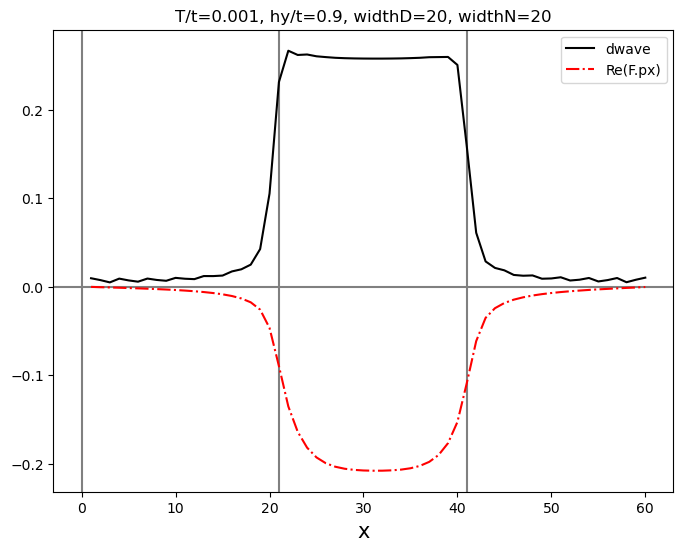

In [21]:
x = np.arange(widthN+widthD+widthN) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))

print(f"T/t={T}, hy/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthN+1, color='gray')
axs.axvline(widthN+widthD+1, color='gray')

axs.plot(x, np.abs(F.dwave), label=r"dwave", color='black')
axs.plot(x, np.real(F.px), "-.", label=r"Re(F.px)", color='red')

axs.set_xlabel("x", fontsize=15)
axs.set_title(f"T/t={T}, hy/t={h0}, widthD={widthD}, widthN={widthN}", )

# axs.set_ylim(None, 0.04)
# axs.set_xlim(-4, 10)
# axs.set_xticks([-4, 0, 5, 10])
plt.legend()
plt.show()